In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

In [68]:
batterIdToHits             = {}
batterIdToAtBats           = {}
batterIdToRbis             = {}
batterIdToPlateAppearences = {}

batterQuery = "SELECT id,b_h,b_ab,b_pa,b_rbi from batters WHERE date between \"2025-01-01\" AND \"2025-12-31\""

connection = sqlite3.connect('player_batting.db')
cursor     = connection.cursor()

cursor.execute(batterQuery)

rows = cursor.fetchall()

for row in rows:
    batterId         = row[0]
    hits             = float(row[1])
    atBats           = float(row[2])
    plateAppearences = float(row[3])
    rbis             = float(row[4])

    if batterId not in batterIdToHits:
        batterIdToHits[batterId] = []
        
    batterIdToHits[batterId].append(hits)

    if batterId not in batterIdToAtBats:
        batterIdToAtBats[batterId] = []
        
    batterIdToAtBats[batterId].append(atBats)

    if batterId not in batterIdToPlateAppearences:
        batterIdToPlateAppearences[batterId] = []

    batterIdToPlateAppearences[batterId].append(plateAppearences)

    if batterId not in batterIdToRbis:
        batterIdToRbis[batterId] = []

    batterIdToRbis[batterId].append(rbis)

cursor    .close()
connection.close()

In [69]:
print(len(batterIdToHits))

1404


In [70]:
print(batterIdToHits["ralec001"][10])

0.0


In [79]:
def getStandardDeviation(data):
    mean = sum(data) / len(data)

    squaredDiffs = [(d - mean) ** 2 for d in data]

    variance = sum(squaredDiffs) / len(data)

    standardDeviation = variance ** 0.5

    return standardDeviation

In [82]:
batterIdToStandardDeviationHits = {}
batterIdToStandardDeviationRbis = {}
standardDeviationsHits = []
standardDeviationsRbis = []

totalGames = 135.0

for batterId in batterIdToHits:
    hits = batterIdToHits[batterId]
    rbis = batterIdToRbis[batterId]

    plateAppearences = sum(batterIdToPlateAppearences[batterId])

    plateAppearencesPerGame = plateAppearences / totalGames

    if plateAppearencesPerGame < 3.1:
        continue

    standardDeviationHits = getStandardDeviation(hits)
    standardDeviationRbis = getStandardDeviation(rbis)

    batterIdToStandardDeviationHits[batterId] = standardDeviationHits
    batterIdToStandardDeviationRbis[batterId] = standardDeviationRbis
    
    standardDeviationsHits.append(standardDeviationHits)
    standardDeviationsRbis.append(standardDeviationRbis)

standardDeviationsHits.sort()
standardDeviationsRbis.sort()

In [83]:
print(len(batterIdToStandardDeviationHits))

136


In [84]:
def get_reverse_percentile(sortedList, value):
    arr = np.array(sortedList)
    count_more_than = np.sum(arr > value)
    percentile = (count_more_than / len(arr)) * 100
    return percentile

In [85]:
batterIdToPercentileHits = {}
batterIdToPercentileRbis = {}

for batterId in batterIdToStandardDeviationHits:
    devHits = batterIdToStandardDeviationHits[batterId]
    devRbis = batterIdToStandardDeviationRbis[batterId]

    percentileHits = get_reverse_percentile(standardDeviationsHits, devHits)
    percentileRbis = get_reverse_percentile(standardDeviationsRbis, devRbis)

    batterIdToPercentileHits[batterId] = percentileHits
    batterIdToPercentileRbis[batterId] = percentileRbis

In [76]:
for batterId in batterIdToPercentile:
    percentile = batterIdToPercentile[batterId]

    meanHits = sum(batterIdToHits[batterId]) / len(batterIdToHits[batterId])

    if percentile < 90.0 and percentile >= 80.0:
        print(f"{batterId}: {batterIdToStandardDeviationHits[batterId]}, {meanHits}")

lowen001: 0.8168284010957434, 0.8145161290322581
bellj005: 0.8126471609273396, 0.7678571428571429
stotb001: 0.8088302059279209, 0.8362068965517241
schwk001: 0.8316640934614791, 0.9224806201550387
ortij005: 0.8285312305519932, 0.744
wittb002: 0.8111467095260881, 1.171875
rengl001: 0.8125663699921729, 0.8571428571428571
lopeo001: 0.8124018779055657, 0.9017857142857143
mccua001: 0.8148049769077487, 0.8558558558558559
contw001: 0.828573133105445, 0.9495798319327731
swand001: 0.8214278132275228, 0.9296875
ralec001: 0.8214278132275228, 0.9296875
loweb001: 0.8203031124295959, 1.0
wagae001: 0.8191310547318422, 0.8245614035087719


In [77]:
meanHits  = []
stdDevs   = []
batterIds = []

for batterId in batterIdToStandardDeviationHits:
    standardDeviation = batterIdToStandardDeviationHits[batterId]

    mean = sum(batterIdToHits[batterId]) / len(batterIdToHits[batterId])

    batterIds.append(batterId)
    meanHits.append(mean)
    stdDevs.append(standardDeviation)

print(len(meanHits))
print(len(stdDevs))

136
136


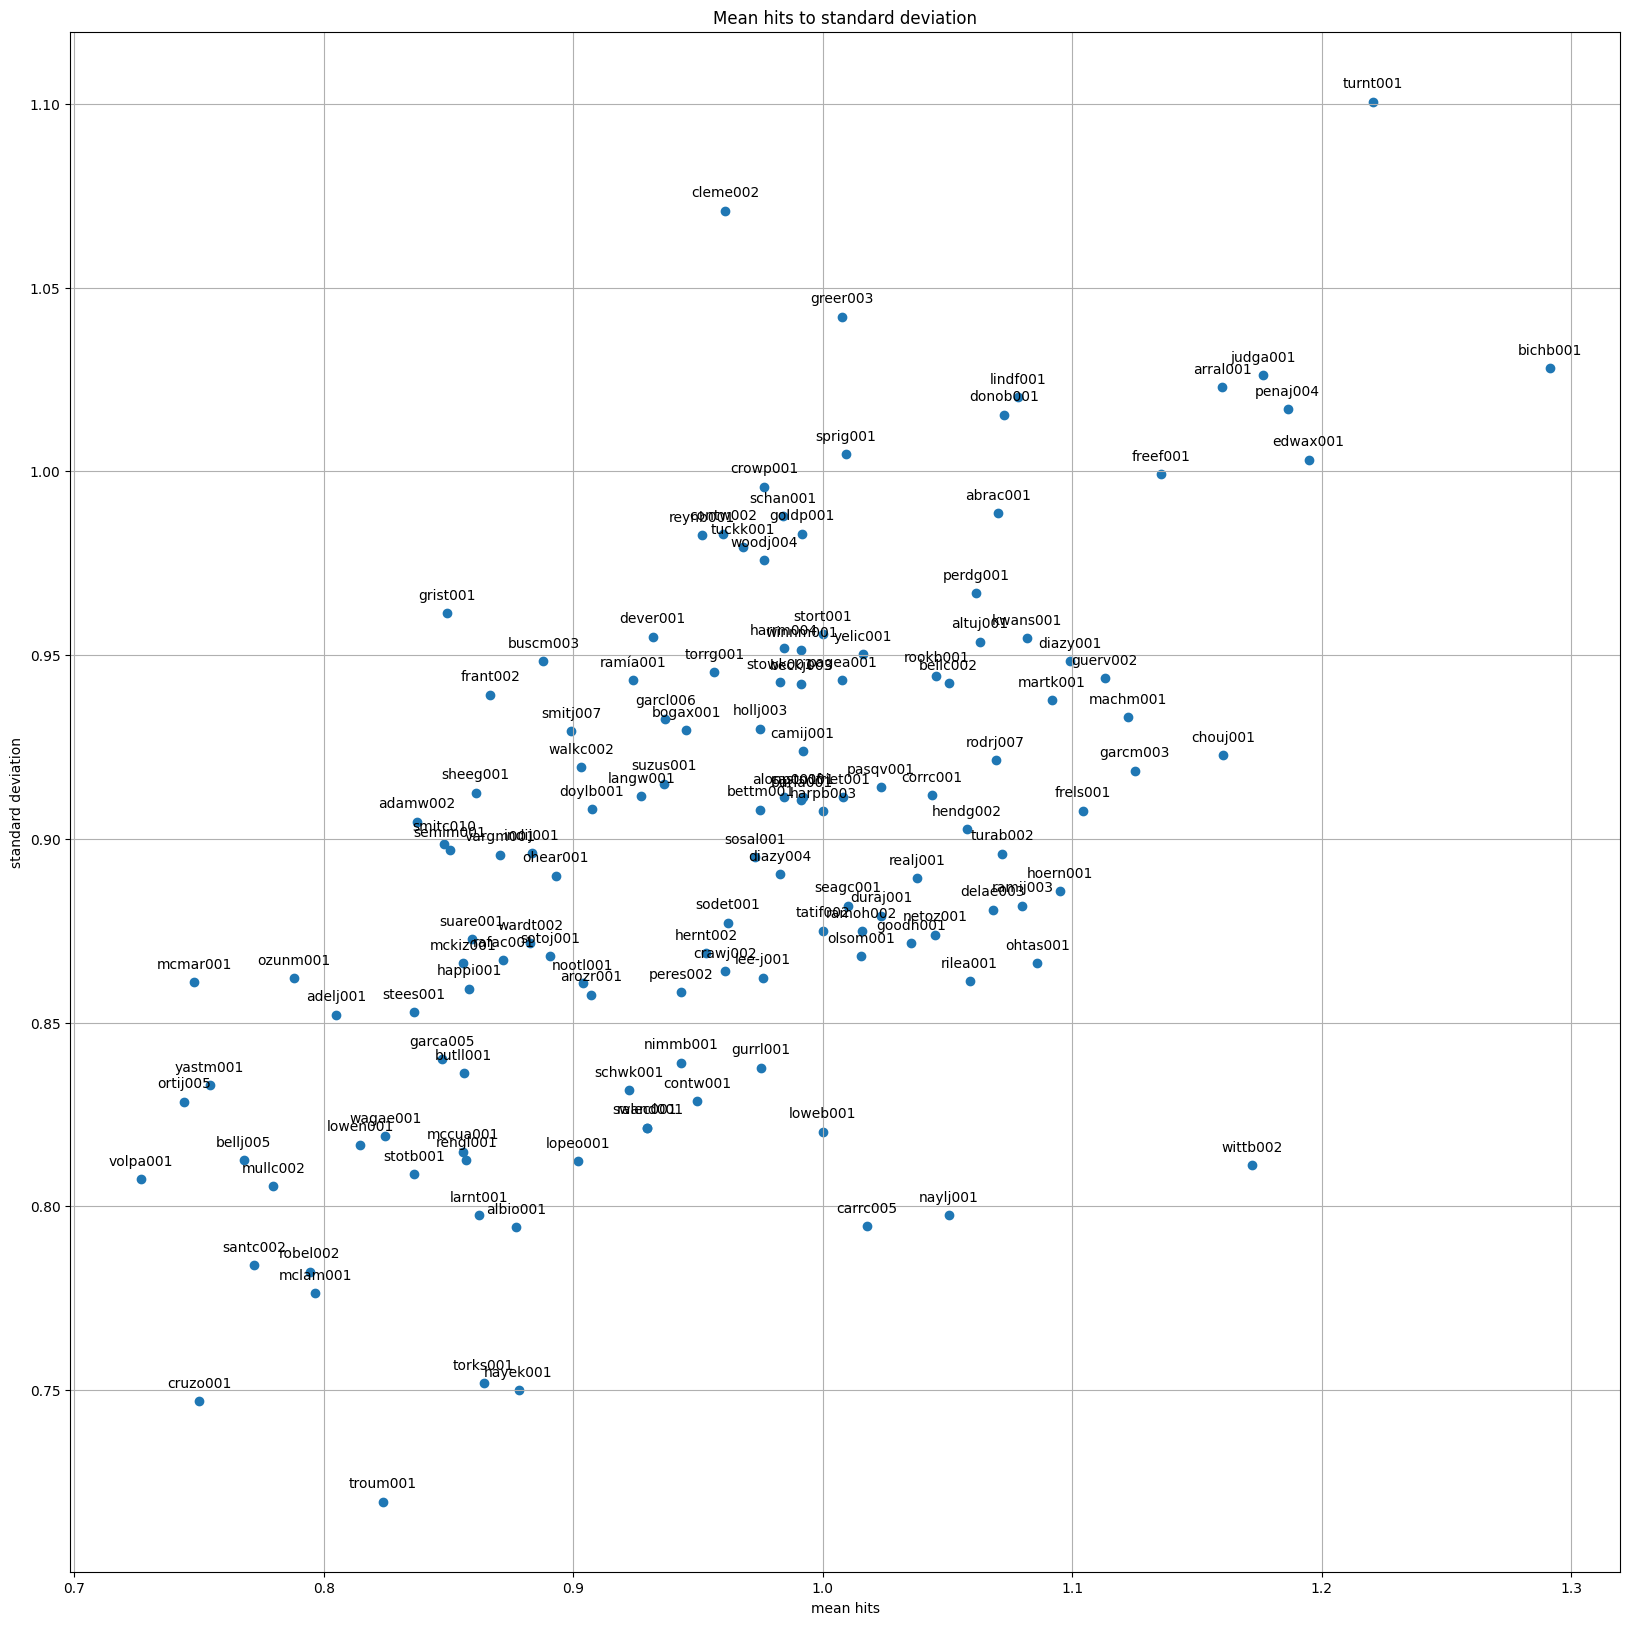

In [78]:
# Create the scatter plot
plt.figure(figsize=(20, 20))
plt.scatter(meanHits, stdDevs)

# Add labels to each point
for i, txt in enumerate(batterIds):
    plt.annotate(txt, (meanHits[i], stdDevs[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Add plot title and axis labels
plt.title('Mean hits to standard deviation')
plt.xlabel('mean hits')
plt.ylabel('standard deviation')

# Display the plot
plt.grid(True)
plt.show()

In [87]:
meanRbis      = []
stdDevsRbis   = []
batterIdsRbis = []

for batterId in batterIdToStandardDeviationRbis:
    std = batterIdToStandardDeviationRbis[batterId]

    mean = sum(batterIdToRbis[batterId]) / len(batterIdToRbis[batterId])

    batterIdsRbis.append(batterId)
    meanRbis     .append(mean)
    stdDevsRbis  .append(std)

print(len(meanRbis))
print(len(stdDevsRbis))

136
136


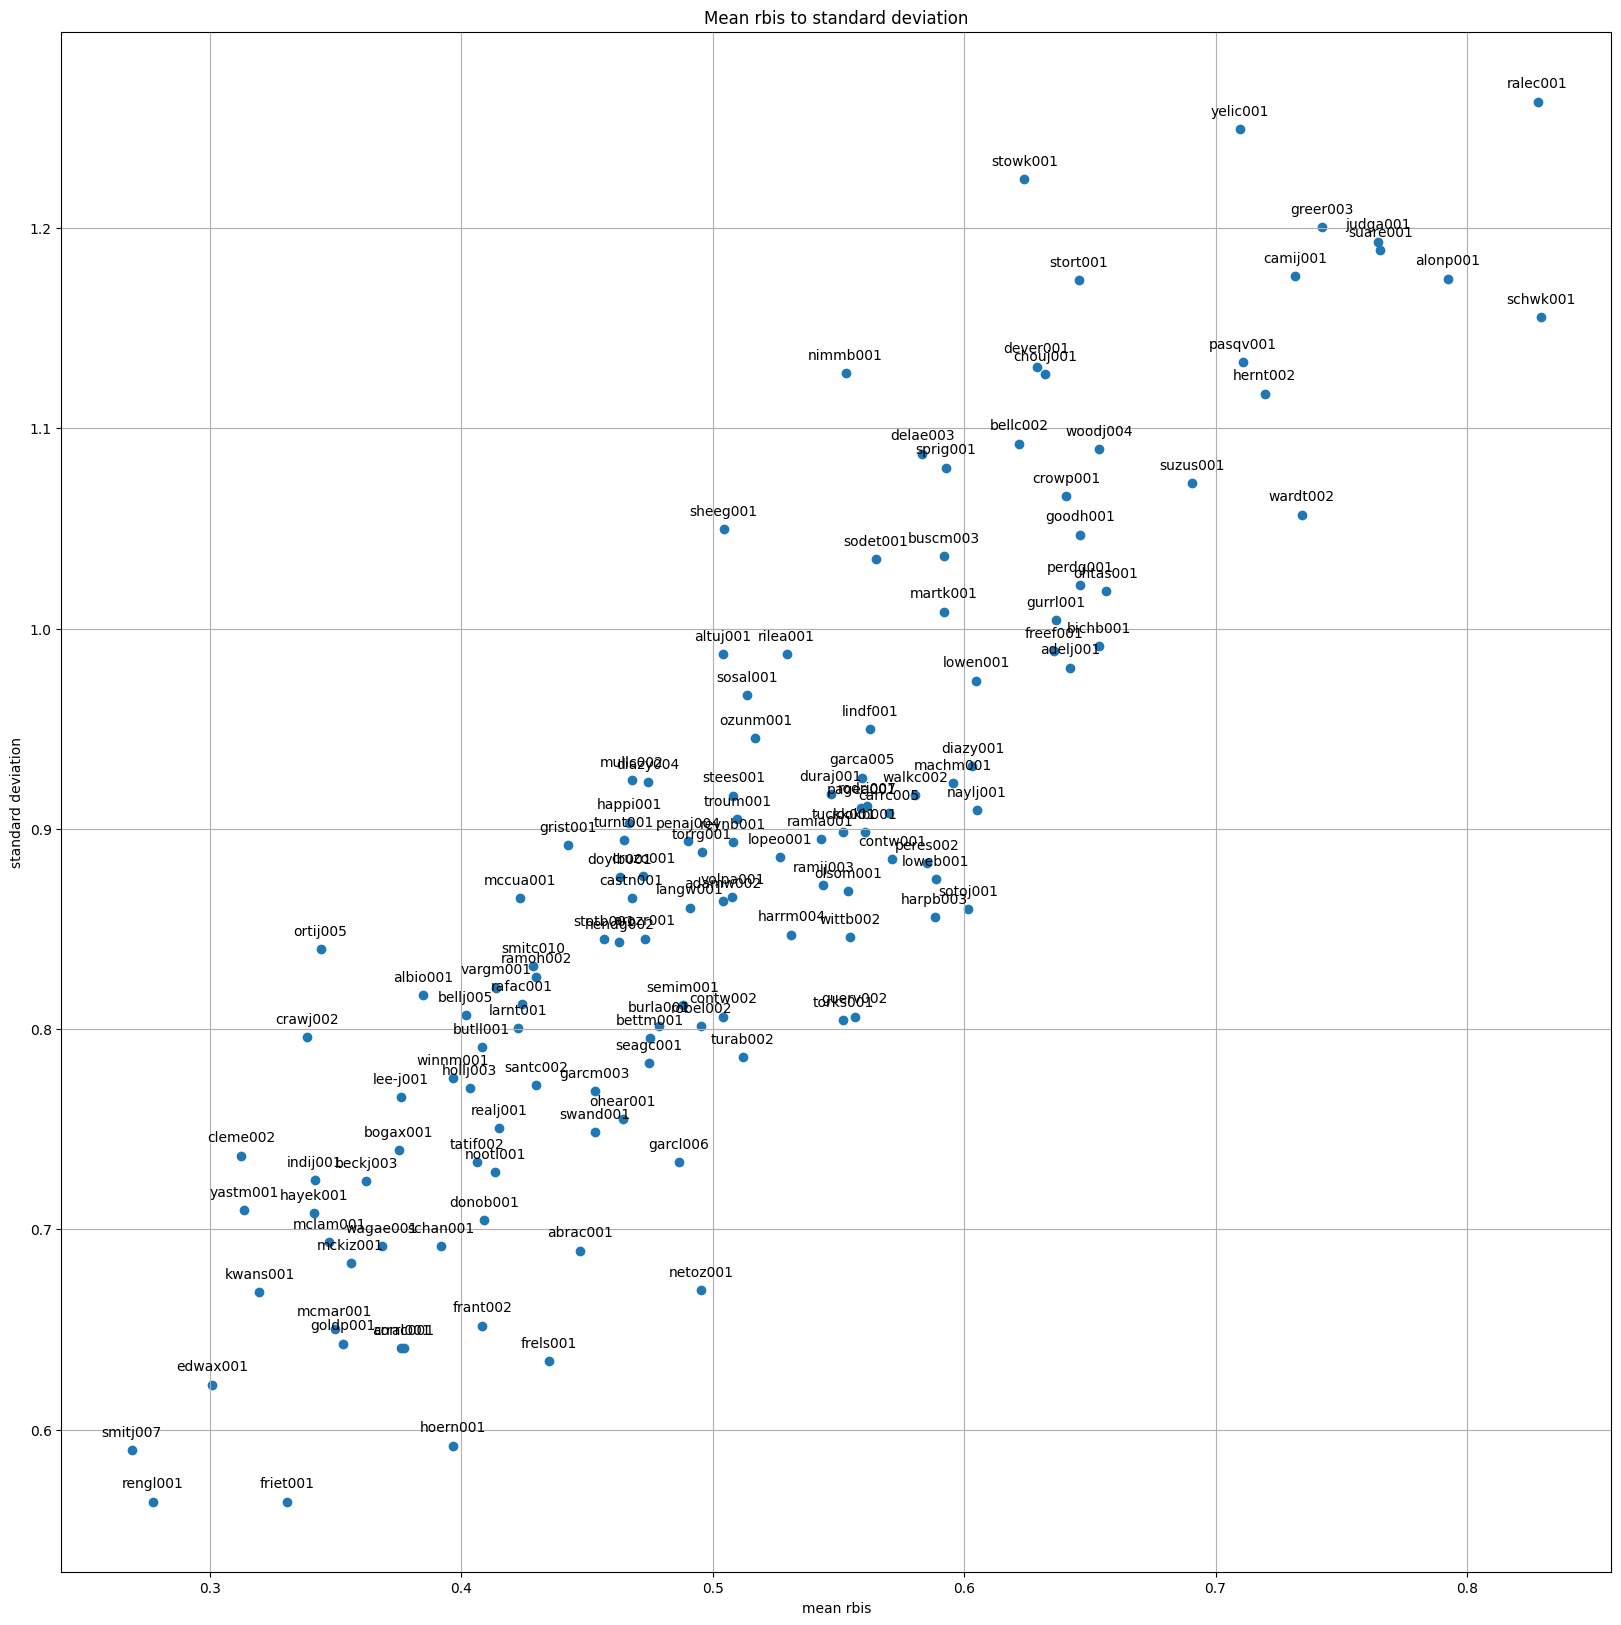

In [88]:
# Create the scatter plot
plt.figure(figsize=(20, 20))
plt.scatter(meanRbis, stdDevsRbis)

# Add labels to each point
for i, txt in enumerate(batterIdsRbis):
    plt.annotate(txt, (meanRbis[i], stdDevsRbis[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Add plot title and axis labels
plt.title('Mean rbis to standard deviation')
plt.xlabel('mean rbis')
plt.ylabel('standard deviation')

# Display the plot
plt.grid(True)
plt.show()